In [2]:
!pip install fastai -q

In [3]:
import fastai

In [4]:
from fastai.metrics import accuracy, F1Score, Recall

In [5]:
from fastai.vision.all import *

path = Path('/kaggle/input/datasets/marierie/crane-origami')
all_files = get_image_files(path)

set_seed(42)
splits = RandomSplitter(valid_pct=0.15, seed=42)(all_files)

In [ ]:
all_files #no need to test now

In [7]:
# shuffle your deck and deal it into two separate piles to be 85% and 15% 1st
train_val_pool, test_idx = RandomSplitter(valid_pct=0.30, seed=42)(all_files) # test set

# setting the 15% from the 85% aside which was the test set and the keeping the 85%
pool_files = all_files[train_val_pool]

# taking that 85% and then spliting it again to 15%
train_sub_idx, val_sub_idx = RandomSplitter(valid_pct=0.20, seed=42)(pool_files) # val

# spliting the train and val
train_idx = train_val_pool[train_sub_idx]
val_idx   = train_val_pool[val_sub_idx]

splits = (train_idx, val_idx, test_idx) # regrouping

60% train 25% test 15% val

In [9]:
print("Train items:", len(splits[0]))
print("Val items:  ", len(splits[1]))
print("Test items: ", len(splits[2]))

Train items: 150
Val items:   37
Test items:  79


In [ ]:
## from fastai.callback.tracker import EarlyStoppingCallback, SaveModelCallback

In [10]:
from fastai.vision.all import *

# 1. Define the DataBlock using a custom lambda function for your pre-calculated indices
dblock = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=lambda o: o,                # Pass items directly since all_files is already a list
    get_y=parent_label,
    splitter=lambda o: (train_idx, val_idx), # Uses your exact train and validation indices
    item_tfms=Resize(256),
    batch_tfms=aug_transforms()
)

# 2. Build training and validation dataloaders using all_files
dls = dblock.dataloaders(all_files, bs=32)

# 3. Create your test dataloader using your test indices
test_files = all_files[test_idx]
test_dl = dls.test_dl(test_files, with_labels=True) # Keeps labels for final evaluation


dls = DataBlock(...).dataloaders(path, bs=64)

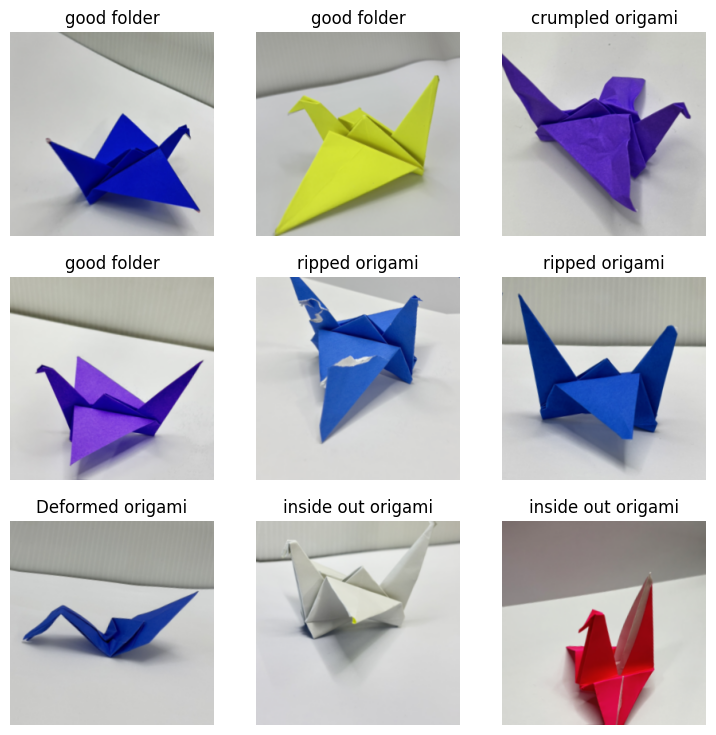

In [11]:
dls.show_batch()

from fastai.metrics import accuracy, F1Score, Recall
from fastai.vision.all import *

In [12]:
metrics_list = [accuracy, F1Score(average='macro'), Recall(average='macro')]
learn = vision_learner(dls, efficientnet_v2_m, metrics=metrics_list) #vision is for calling fastai test efficent or resnet or other models

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_V2_M_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_V2_M_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_v2_m-dc08266a.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_m-dc08266a.pth


100%|██████████| 208M/208M [00:01<00:00, 211MB/s] 


learn.fine_tune(75) VVVV

In [13]:
!nvidia-smi

Thu Jun 11 14:31:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P0             26W /   70W |     375MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [14]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')
else:
    print('No GPU detected')

Using device: cuda
GPU: Tesla T4
VRAM: 15.64 GB


In [ ]:
#learn.fine_tune(
    #epochs=50, # Set a high upper bound
    ##cbs=[
        ##EarlyStoppingCallback(monitor='valid_loss', patience=6),
        #3SaveModelCallback(monitor='valid_loss', fname='best_model')
    ##]
##)

In [15]:
learn.fine_tune(50)

epoch,train_loss,valid_loss,accuracy,f1_score,recall_score,time
0,2.892713,2.286352,0.081081,0.041379,0.120000,00:05


epoch,train_loss,valid_loss,accuracy,f1_score,recall_score,time
0,1.880739,1.913181,0.216216,0.209697,0.268182,00:05
1,1.699334,1.632725,0.378378,0.366478,0.427727,00:05
2,1.659109,1.377004,0.540541,0.509464,0.550455,00:05
3,1.582206,1.293261,0.513514,0.470163,0.488636,00:05
4,1.446812,1.185857,0.567568,0.536121,0.553636,00:05
5,1.351884,1.003553,0.621622,0.598615,0.596818,00:05
6,1.277140,0.963406,0.567568,0.517013,0.523636,00:05
7,1.201792,0.910711,0.594595,0.534602,0.533636,00:05
8,1.156037,0.851282,0.621622,0.578874,0.580455,00:05
9,1.105112,0.801495,0.702703,0.695900,0.700455,00:05


In [16]:
test_metrics = learn.validate(dl=test_dl)

print(f"Test Loss:     {test_metrics[0]:.4f}") # Aim for 30
print(f"Test Accuracy: {test_metrics[1]:.4f}") #Aim for High Recall (95 - 99) or 85 up
print(f"Test F1 Score: {test_metrics[2]:.4f}") # Aim for 80
print(f"Test Recall:   {test_metrics[3]:.4f}") # Aim for 85

Test Loss:     0.8138
Test Accuracy: 0.7595
Test F1 Score: 0.7575
Test Recall:   0.7676


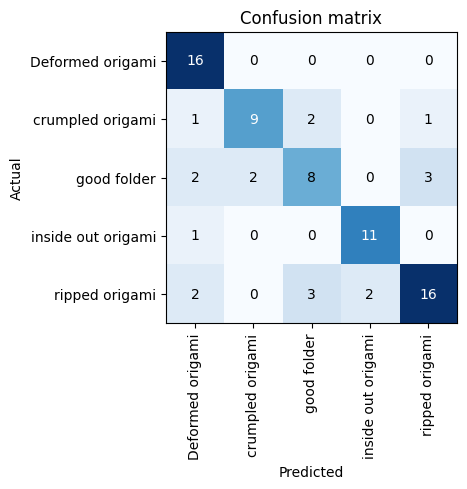

In [17]:
# Create an interpretation object focused strictly on your test set
interp = ClassificationInterpretation.from_learner(learn, dl=test_dl)

interp.plot_confusion_matrix() # plotting the matrix


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


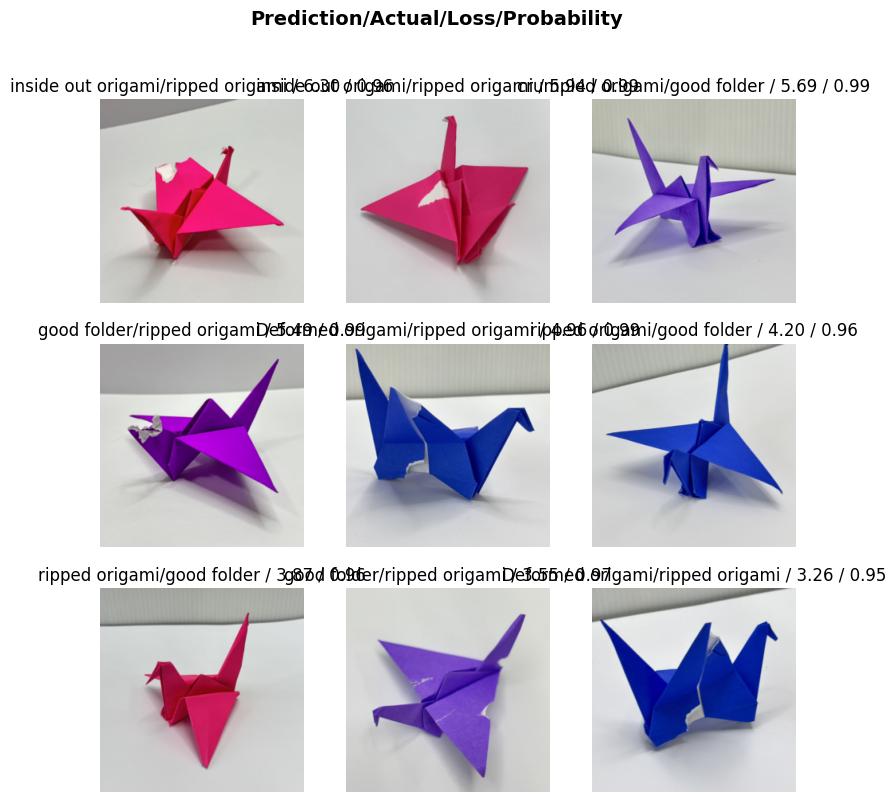

In [18]:
interp.plot_top_losses(k=9, nrows=3) # extra: display what it failed to classify(TOP 3)

exporting section

In [19]:
learn.export() 

In [20]:
!ls /kaggle/working

export.pkl


In [21]:
!ls /kaggle/input/datasets/marierie/crane-origami

'Crane origami'


In [ ]:
!ls "/kaggle/input/datasets/marierie/crane-origami/Crane origami"

In [ ]:
from fastai.vision.all import *

# Path to your images
path = Path('/kaggle/input/datasets/marierie/crane-origami/Crane origami')

# Create the DataBlock using the good/bad folders
dls = ImageDataLoaders.from_folder(path, train='.', valid_pct=0.2, item_tfms=Resize(224))

# Train a quick model
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(3)

# Now you can export it!
learn.export()

In [24]:
# 1. Provide a real path to an image in your Kaggle dataset
img_path = '/kaggle/input/datasets/marierie/crane-origami/Crane origami/bad folder/Deformed origami/Deformed16.jpg'

# 3. Get the prediction
pred, pred_idx, probs = learn.predict(img_path)

# 4. Display the results safely using .item()
print(f"Prediction: {pred}")
print(f"Class Index: {pred_idx}")
print(f"Probability: {probs[pred_idx].item():.4f}")


Prediction: Deformed origami
Class Index: 0
Probability: 1.0000


0 = deformed
1 = 
2 = good
3 = inside-out
4 = 

In [22]:
!python --version ## VScode has a different version from kaggle

Python 3.12.13


In [25]:
import fastai, fastcore, torch, pydantic
print("fastai", fastai.__version__)
print("fastcore", fastcore.__version__)
print("torch", torch.__version__)
print("pydantic", pydantic.__version__)

fastai 2.8.7
fastcore 1.12.36
torch 2.10.0+cu128
pydantic 2.12.3
